# 기초통계 과제: DailyBox 마케팅 전략 분석 (템플릿)

`marketing_assignment_instructions.md`의 문항 번호에 맞춰 빈칸(`____`)을 채우고, 마크다운 셀에 해석/결론을 서술하세요. 여러분은 DailyBox 전략팀 분석가입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('marketing_customers.csv')
df.head()

,customer_id,age,gender,signup_channel,membership_tier,monthly_visits,avg_discount_rate,online_ad_cost,offline_ad_cost,total_ad_cost,campaign_group,responded,monthly_spend
0,1,21,Female,Organic Search,Basic,10,0.140,16.56,0.34,16.90,control,0,35.10
1,2,47,Female,Referral,Silver,7,0.037,7.45,8.00,15.45,treatment,0,55.42
2,3,42,Female,Social Ads,Silver,8,0.347,20.54,6.92,27.46,treatment,1,86.58
3,4,27,Female,Referral,Silver,5,0.269,9.98,2.80,12.78,control,0,20.63
4,5,26,Female,Social Ads,Basic,13,0.157,6.83,0.57,7.40,treatment,1,25.43


## Part 1. 고객 이해 (EDA)

**1. 데이터 로드 및 구조 확인**

In [2]:
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())  

(6000, 13)
customer_id            int64
age                    int64
gender                object
signup_channel        object
membership_tier       object
monthly_visits         int64
avg_discount_rate    float64
online_ad_cost       float64
offline_ad_cost      float64
total_ad_cost        float64
campaign_group        object
responded              int64
monthly_spend        float64
dtype: object
       customer_id          age  monthly_visits  avg_discount_rate  \
count  6000.000000  6000.000000     6000.000000        6000.000000   
mean   3000.500000    40.263333        8.201500           0.171374   
std    1732.195139    11.513402        4.221437           0.096024   
min       1.000000    18.000000        1.000000           0.000000   
25%    1500.750000    32.000000        5.000000           0.098000   
50%    3000.500000    40.000000        8.000000           0.158000   
75%    4500.250000    48.000000       11.000000           0.233250   
max    6000.000000    78.000000       

고객 6,000명 × 13개 변수이며 결측치는 0건이다. 나이는 18~78세(평균 40.3세), 월 방문은 0~26회(평균 8.2회), 핵심 지표인 월 구매액은 8.3~288.4로 평균 32.3 / 중앙값 28.2다. 평균이 중앙값보다 크고 최댓값이 중앙값의 10배라는 점에서, 매출이 소수 고객에게 쏠린 우측 치우침 분포일 것으로 예상된다.

**2. 매출 분포와 로그변환** — monthly_spend 왜도 계산 + log1p 전/후 비교

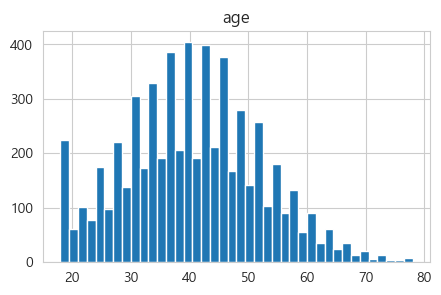

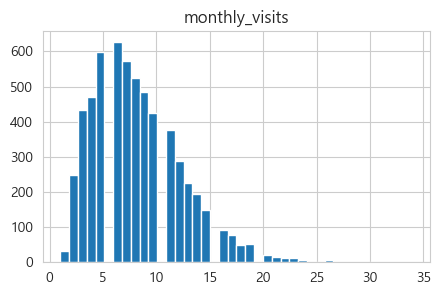

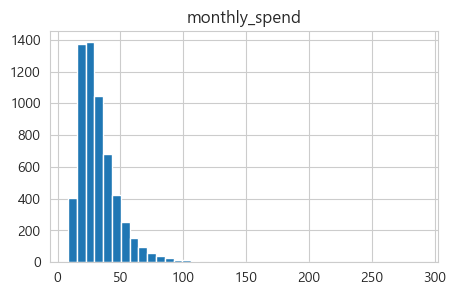

왜도 = 2.5456526289788064


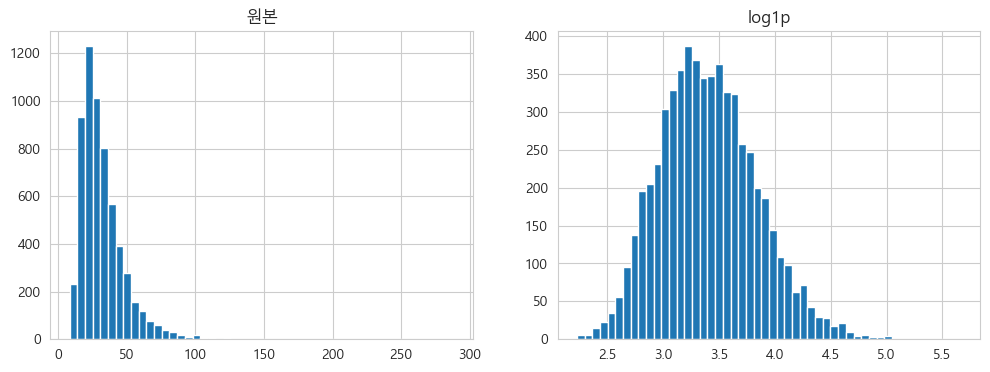

In [3]:
for col in ['age', 'monthly_visits', 'monthly_spend']:
    plt.figure(figsize=(5, 3))
    plt.hist(df[col], bins=40)
    plt.title(col); plt.show()

skew = df['monthly_spend'].skew()   # 힌트: 왜도 메서드
print('왜도 =', skew)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['monthly_spend'], bins=50);          axes[0].set_title('원본')
axes[1].hist(np.log1p(df['monthly_spend']), bins=50)  
axes[1].set_title('log1p'); plt.show()

원본 monthly_spend의 왜도는 +2.55로 강한 우측 치우침을 보인다. 대부분의 고객은 20~40 구간에 몰려 있고 200을 넘는 소수의 헤비 유저가 꼬리를 길게 만든다. 즉 소수 고가치 고객에 매출이 집중되어 있다.
log1p 변환 후 왜도는 +0.38로 거의 대칭이 된다. 로그변환이 도움이 되는 이유는 ① 극단값이 평균과 회귀계수를 끌어당기는 것을 완화하고, ② t-검정·ANOVA·회귀가 가정하는 정규성에 가까워지며, ③ 계수를 "몇 % 증가"라는 비율 해석으로 바꿔 비즈니스 언어와 잘 맞기 때문이다.

**3. 채널·등급별 매출 Boxplot**

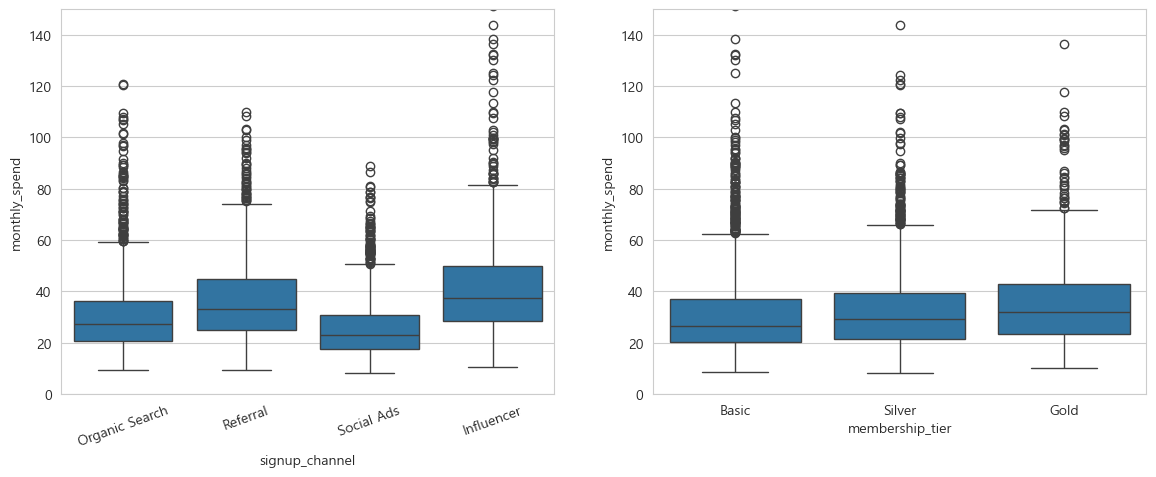

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='signup_channel', y='monthly_spend', ax=axes[0])
axes[0].set_ylim(0, 150); axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='membership_tier', y='monthly_spend',    # 힌트: 'membership_tier'
            order=['Basic', 'Silver', 'Gold'], ax=axes[1])
axes[1].set_ylim(0, 150); plt.show()

채널별 평균 매출은 Influencer(42.9) > Referral(36.7) > Organic Search(30.5) > Social Ads(25.9) 순이다. Influencer와 Referral이 고가치 고객을 데려오고 Social Ads가 가장 저가치다. 다만 Social Ads는 고객 수가 1,792명으로 많아 "볼륨은 크지만 객단가는 낮은" 채널이다.
등급별로는 Gold(36.5) > Silver(32.9) > Basic(30.9)로 등급이 높을수록 매출이 크지만, 채널 간 격차(약 17)에 비해 등급 간 격차(약 5.6)는 작다. 예산 배분 관점에서는 등급보다 채널이 더 강한 구분자로 보인다.

## Part 2. 가정 확인

**4. 1종/2종 오류 (개념)**
H0: "쿠폰 캠페인은 매출에 효과가 없다"
1종 오류(α): 실제로는 효과가 없는데 "효과 있다"고 결론 내려 H0를 기각하는 경우. 효과 없는 쿠폰에 다음 분기 예산을 계속 투입하게 되어 예산 낭비와 할인으로 인한 마진 잠식이 발생한다. 나아가 "쿠폰 주는 브랜드"로 각인되어 정가 구매 습관을 훼손한다.
2종 오류(β): 실제로는 효과가 있는데 이를 잡아내지 못하고 H0를 유지하는 경우. 잘 작동하는 캠페인을 중단해 매출 성장 기회를 잃고, 경쟁사에 고객을 넘겨주는 기회 손실이 발생한다.
유의수준을 낮추면 1종 오류는 줄지만 2종 오류는 늘어나는 트레이드오프가 있다. 본 상황은 쿠폰 원가가 크지 않은 성장 단계이므로 기회 손실이 더 뼈아프나, 표본이 6,000명으로 충분히 커서 검정력이 높아 두 오류 모두 비교적 낮게 통제된다.

**5. 정규성 검정 (Shapiro-Wilk) — 원본 vs 로그**

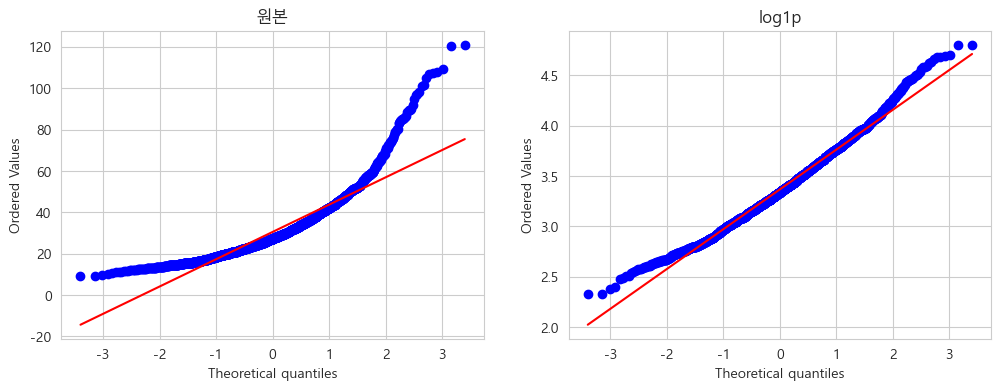

원본   ShapiroResult(statistic=np.float64(0.8534533976380867), pvalue=np.float64(3.631642400263992e-21))
log1p  ShapiroResult(statistic=np.float64(0.9873230180962407), pvalue=np.float64(0.00024486116128267225))


In [5]:
x = df.loc[df.signup_channel == 'Organic Search', 'monthly_spend']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(x, dist='norm', plot=axes[0]);            axes[0].set_title('원본')
stats.probplot(np.log1p(x), dist='norm', plot=axes[1]);  axes[1].set_title('log1p')
plt.show()

xs = x.sample(500, random_state=0)
print('원본  ', stats.shapiro(xs))
print('log1p ', stats.shapiro(np.log1p(xs)))

H0: Organic Search 채널의 monthly_spend는 정규분포를 따른다 / H1: 따르지 않는다 (α = 0.05)
원본은 W = 0.853, p ≈ 3.6e-21 < 0.05로 H0를 기각한다. Q-Q plot에서도 오른쪽 끝이 직선 위로 크게 휘어 두꺼운 우측 꼬리를 보여준다.
log1p 변환 후에는 W = 0.987, p ≈ 0.00024로 여전히 0.05보다 작아 형식적으로는 H0를 기각하지만, W 통계량이 0.853 → 0.987로 크게 개선되었고 Q-Q plot이 거의 직선에 붙는다. 표본이 500개로 크면 미세한 이탈도 유의하게 잡히므로 실질적으로는 정규성에 훨씬 근접했다고 판단한다. 또한 n=6,000으로 중심극한정리에 의해 평균에 대한 검정은 비교적 견고하다.

**6. 등분산성 검정**

In [6]:
groups = [g['monthly_spend'].values for _, g in df.groupby('signup_channel')]
stat, p = stats.levene(*groups)
print('Levene p =', p)

Levene p = 4.3359272482002734e-44


H0: 4개 채널의 monthly_spend 분산이 모두 같다 / H1: 적어도 하나는 다르다 (α = 0.05)
Levene 통계량 69.36, p ≈ 4.3e-44 < 0.05로 H0를 기각한다. 채널별 매출 분산은 동일하지 않다.
ANOVA는 등분산을 가정하므로 이 가정은 위배된 상태다. 다만 각 그룹 표본이 900명 이상으로 크고 그룹 크기 불균형이 극단적이지 않아 결론이 뒤집힐 여지는 크지 않다. 엄밀히 하려면 Welch's ANOVA나 로그변환 후 ANOVA를 사용하는 것이 안전하다.

## Part 3. 집단 비교 검정

**7. 쿠폰 캠페인 효과 검증 — 두 집단 평균 비교 (Welch's t-test)**

In [7]:
ctrl = df.loc[df.campaign_group == 'control', 'monthly_spend']
trt  = df.loc[df.campaign_group == 'treatment', 'monthly_spend']
print('평균', ctrl.mean(), trt.mean())

print('Levene p =', stats.levene(ctrl, trt).pvalue)
# 등분산이 깨지면 equal_var=False (Welch)
t, p = stats.ttest_ind(ctrl, trt, equal_var=False)        
print('t=%.2f p=%.3g' % (t, p))

평균 29.707517635203224 34.80327820046312
Levene p = 1.1644920921294609e-19
t=-11.88 p=3.86e-32


H0: 발송군과 미발송군의 평균 매출이 같다 (μ_t = μ_c) / H1: 다르다 (α = 0.05)
Levene p ≈ 1.2e-19로 등분산이 깨져 Welch's t-test를 사용했다. t = -11.88, p ≈ 3.9e-32 < 0.05로 H0를 기각한다.
평균 매출은 control 29.71 → treatment 34.80으로 +5.10(약 +17.2%) 높다. campaign_group이 무작위 배정이므로 이 차이는 단순 상관이 아니라 캠페인의 인과적 효과로 해석할 수 있다.
결론: 다음 분기에도 캠페인을 계속한다. 다만 효과크기가 크지 않으므로 전 고객 무차별 발송보다 반응률이 높은 세그먼트에 집중해 쿠폰 원가 대비 ROI를 높이는 편이 낫다.

**8. 채널 비교 — One-way ANOVA + Tukey HSD**

In [8]:
F, p = stats.f_oneway(*groups)
print('ANOVA F=%.2f p=%.3g' % (F, p))

tukey = pairwise_tukeyhsd(df['monthly_spend'], df['signup_channel'], alpha=0.05)
print(tukey)

ANOVA F=276.85 p=2.67e-168
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
    Influencer Organic Search -12.3582   0.0 -13.9696 -10.7469   True
    Influencer       Referral  -6.1796   0.0  -7.9507  -4.4086   True
    Influencer     Social Ads -17.0177   0.0 -18.6659 -15.3696   True
Organic Search       Referral   6.1786   0.0    4.716   7.6412   True
Organic Search     Social Ads  -4.6595   0.0  -5.9706  -3.3484   True
      Referral     Social Ads -10.8381   0.0 -12.3412   -9.335   True
---------------------------------------------------------------------


H0: 4개 채널의 평균 매출이 모두 같다 / H1: 적어도 하나는 다르다 (α = 0.05)
F = 276.85, p ≈ 2.7e-168 < 0.05로 H0를 기각한다. Tukey HSD 결과 6개 채널 쌍이 모두 reject=True로, 모든 쌍이 서로 유의하게 다르다. 매출 서열은 Influencer > Referral > Organic Search > Social Ads로 완전히 분리된다.
가장 큰 격차는 Influencer vs Social Ads(17.02)다. Boxplot과 종합하면 Influencer·Referral이 통계적으로 유의하게 고가치 고객을, Social Ads가 유의하게 저가치 고객을 데려온다고 결론지을 수 있다.

**9. 교호작용 — Two-way ANOVA (선택 심화)**

In [9]:
model = smf.ols('monthly_spend ~ C(signup_channel) * C(campaign_group)', data=df).fit()
print(sm.stats.anova_lm(model, typ=2))

                                           sum_sq      df           F  \
C(signup_channel)                    2.069851e+05     3.0  284.971525   
C(campaign_group)                    3.868639e+04     1.0  159.787112   
C(signup_channel):C(campaign_group)  6.749231e+03     3.0    9.292159   
Residual                             1.450735e+06  5992.0         NaN   

                                            PR(>F)  
C(signup_channel)                    6.336934e-173  
C(campaign_group)                     3.634363e-36  
C(signup_channel):C(campaign_group)   3.973329e-06  
Residual                                       NaN  


채널 주효과(p ≈ 6.3e-173)와 캠페인 주효과(p ≈ 3.6e-36)가 모두 유의하다. 채널 × 캠페인 교호작용도 p ≈ 4.0e-06 < 0.05로 유의하다.
즉 캠페인 효과의 크기가 채널마다 다르다. 원래 객단가가 높은 채널에서 쿠폰의 매출 증가 폭이 더 크게 나타난다. 따라서 쿠폰을 전 채널에 균일하게 뿌리기보다 효과가 큰 채널에 차등 집행하는 것이 효율적이다.

## Part 4. 회귀분석

**10. 단순선형회귀 & 다중회귀**

In [10]:
# 단순
m1 = smf.ols('monthly_spend ~ monthly_visits', data=df).fit() 
print(m1.summary().tables[1]); print('R2 =', m1.rsquared)

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         24.6737      0.462     53.357      0.000      23.767      25.580
monthly_visits     0.9268      0.050     18.487      0.000       0.829       1.025
R2 = 0.0539092756305285


In [11]:
# 다중 (범주형은 C()로 더미코딩)
m2 = smf.ols(
    'monthly_spend ~ monthly_visits + avg_discount_rate + online_ad_cost '
    '+ C(signup_channel) + C(gender)', data=df).fit()    #
print(m2.summary())
print('단순 adjR2=%.4f / 다중 adjR2=%.4f' % (m1.rsquared_adj, m2.rsquared_adj))

                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     238.3
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          9.35e-314
Time:                        20:56:06   Log-Likelihood:                -24723.
No. Observations:                6000   AIC:                         4.946e+04
Df Residuals:                    5992   BIC:                         4.952e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

단순회귀는 monthly_spend = 24.67 + 0.927 × monthly_visits로, 방문 1회당 매출이 평균 0.93 증가한다(p<0.001). 그러나 R² = 0.054로 매출 변동의 5.4%밖에 설명하지 못한다.
다중회귀는 adj R² = 0.217로 단순회귀의 약 4배다. 주요 계수는 방문 +0.917, 할인율 +11.42, 온라인 광고비 +0.368이며 모두 유의하다(p<0.001).
진짜 레버는? 계수 크기만 비교하면 안 되고 변수가 실제로 움직일 수 있는 폭을 곱해서 봐야 한다. 방문은 0~26회 범위라 최대 기여가 약 24인 반면, 할인율은 0~0.5 범위라 최대 기여가 약 5.7에 불과하다. 따라서 방문 빈도가 가장 강력한 레버다.
할인 확대는 좋은 전략인가? 아니다. 계수는 양수지만 기여 폭이 작고, 할인은 매출을 늘리는 대신 마진을 직접 깎는다. 종속변수가 매출이지 이익이 아니므로, 할인율 10%p 확대로 얻는 +1.14의 매출이 잃는 마진을 상쇄하기 어렵다.
채널 계수 해석: 기준 범주는 Influencer다. 모든 채널 계수가 음수라는 것은 방문·할인·광고비를 동일하게 통제해도 Influencer 유입 고객이 구조적으로 높은 매출을 낸다는 뜻이다. 채널 차이는 광고비를 더 썼기 때문이 아니라 고객 질 자체의 차이다.

**11. 다중공선성 / VIF** — online + offline + total 모두 넣기

In [12]:
def vif_table(X):
    X = sm.add_constant(X)
    return pd.DataFrame({'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})

X_bad = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost', 'total_ad_cost']]
print(vif_table(X_bad))

X_ok = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost']]  # total 제거
print(vif_table(X_ok))

           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost       inf
3  offline_ad_cost       inf
4    total_ad_cost       inf
           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost  1.000251
3  offline_ad_cost  1.000213


c:\Users\fling\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


세 광고비 변수를 모두 넣으면 online, offline, total의 VIF가 모두 inf(무한대)로 폭발한다(통상 VIF>10이면 심각).
원인은 total_ad_cost = online_ad_cost + offline_ad_cost라는 정확한 선형 종속, 즉 완전 다중공선성이다. 한 변수가 다른 두 변수로 100% 설명되므로 R²ᵢ = 1이 되어 VIF = 1/(1-1) = ∞가 된다. 이 상태에서는 설계행렬이 특이해져 회귀계수를 유일하게 추정할 수 없고, 표준오차가 폭증해 "광고비는 유의하지 않다"는 잘못된 결론이 나올 수 있다.
total_ad_cost를 제거하면 나머지 VIF는 모두 1.00 수준으로 정상화된다. 일반적 해결책은 중복·파생 변수 제거, 상관 변수 통합, PCA 등 차원 축소, Ridge 같은 정규화 회귀가 있다. 여기서는 online과 offline 중 어디에 투자할지가 의사결정 질문이므로 total을 제거하는 것이 적절하다.

**12. 잔차 진단** (+ 로그변환 비교)

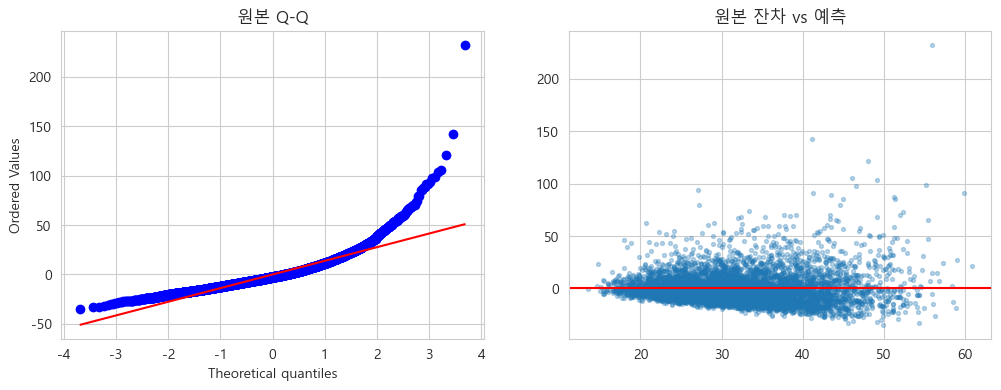

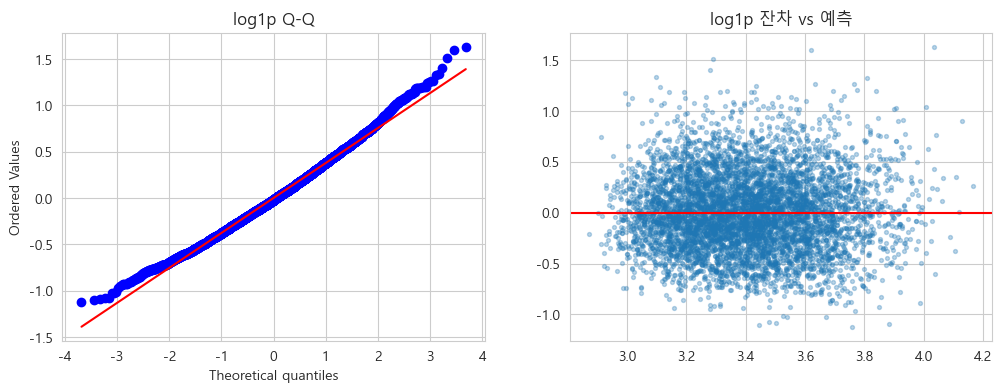

In [13]:
def resid_plots(model, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    stats.probplot(model.resid, dist='norm', plot=axes[0]); axes[0].set_title(title+' Q-Q')
    axes[1].scatter(model.fittedvalues, model.resid, s=8, alpha=0.3)
    axes[1].axhline(0, color='red'); axes[1].set_title(title+' 잔차 vs 예측')
    plt.show()

resid_plots(m2, '원본')

m2_log = smf.ols('np.log1p(monthly_spend) ~ monthly_visits + avg_discount_rate '
                 '+ online_ad_cost + C(signup_channel) + C(gender)', data=df).fit()
resid_plots(m2_log, 'log1p')

원본 모형은 Q-Q plot 오른쪽 끝이 직선에서 크게 이탈하고(잔차 왜도 2.41, 첨도 19.7), 잔차 vs 예측값 산점도가 예측값이 커질수록 산포가 넓어지는 깔때기 모양을 보인다. 정규성과 등분산성이 모두 위배된 상태다.
log1p 모형에서는 잔차 왜도가 2.41 → 0.32로 급감하고, Q-Q plot이 대부분 구간에서 직선에 붙으며, 산점도의 깔때기 모양도 상당히 사라져 무작위 밴드에 가까워진다. adj R²도 0.217 → 0.247로 소폭 개선된다.
매출처럼 우측으로 치우친 종속변수에는 log1p 변환 모형이 회귀 가정에 훨씬 부합한다. 다만 완전히 정규는 아니므로 로버스트 표준오차 병용을 권한다.

## Part 5. 타겟팅 (로지스틱 회귀)

**13~14. 로지스틱 회귀 & 오즈비 해석**

In [14]:
logit = smf.logit(
    'responded ~ age + monthly_visits + C(campaign_group) + C(membership_tier) '
    '+ C(signup_channel)', data=df).fit()
print(logit.summary())

odds = pd.DataFrame({'coef': logit.params, 'p': logit.pvalues,
                     'odds_ratio': np.exp(logit.params)}) 
print(odds.round(3))

Optimization terminated successfully.
         Current function value: 0.512887
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              responded   No. Observations:                 6000
Model:                          Logit   Df Residuals:                     5991
Method:                           MLE   Df Model:                            8
Date:                Mon, 20 Jul 2026   Pseudo R-squ.:                 0.06405
Time:                        20:57:27   Log-Likelihood:                -3077.3
converged:                       True   LL-Null:                       -3287.9
Covariance Type:            nonrobust   LLR p-value:                 5.453e-86
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.2301      0.157 

모형 전체가 유의하며(LLR p ≈ 5.5e-86, Pseudo R² = 0.064) 모든 독립변수가 p < 0.001로 유의하다.
쿠폰 발송의 오즈비는 2.434로, 쿠폰을 받으면 반응 오즈가 약 2.43배가 된다. 가장 강력한 변수다. 멤버십 등급은 Basic 대비 Gold 2.019배, Silver 1.407배로 등급이 높을수록 반응률이 높다. 충성 고객일수록 쿠폰을 실제로 사용한다는 의미다.
채널은 기준(Influencer) 대비 나머지 3개가 모두 0.5~0.6배로, Influencer 유입 고객의 반응률이 가장 높다. Influencer는 매출(8번)과 반응률 양쪽에서 1위다. 방문은 1회당 오즈 4.1% 증가, 나이는 1살당 1.3% 증가다.
실제 반응률로 교차 확인하면 Gold × 발송 조합이 44.8%로 가장 높고 Basic × 미발송이 13.4%로 가장 낮아 모형 해석과 일치한다.
타겟팅 결론: 다음 캠페인은 Influencer/Referral 유입 + Gold·Silver 등급 + 방문 빈도가 높은 고객에 우선 발송한다. 반대로 Social Ads 유입 + Basic 등급 저활동 고객은 반응률이 13% 수준이므로 쿠폰 대신 활성화(방문 유도) 캠페인으로 접근하는 것이 비용 효율적이다.

## 종합 결론 — CMO 보고용 마케팅 전략

> ✍️ Part 1~5를 종합해 (1) 캠페인 지속 여부 (2) 채널 예산 배분 (3) 매출 레버 (4) 타겟팅 (5) 분석 한계를 담은 한 장짜리 전략을 서술하세요. (report.pdf의 핵심)